# DeepShield Detect — Notebook 1: Data Preparation

**Objective:** Load the `140k Real and Fake Faces` dataset, detect faces using MTCNN, normalize, split, and save the data ready for training.

| Parameter | Value |
|---|---|
| Dataset | 140k Real and Fake Faces (Kaggle) |
| Face Detection | MTCNN |
| Image Size | 224 × 224 px |
| Split | 70% train / 15% val / 15% test |


---


## Imports & Configuration

We import all necessary libraries and define the paths to the data.  
Make sure the **(venv)** Python kernel is selected in the top right corner of VSCode.

In [1]:
import os, random, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf

warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────
REAL_DIR  = r'..\data\real'
FAKE_DIR  = r'..\data\fake'
IMG_SIZE  = 224
MAX_IMGS  = 2000   # réduis à 3000 si RAM < 8 Go
SEED      = 42
random.seed(SEED)
np.random.seed(SEED)

print('TensorFlow :', tf.__version__)
print('GPU dispo  :', tf.config.list_physical_devices('GPU'))
print('REAL_DIR   :', os.path.abspath(REAL_DIR))
print('FAKE_DIR   :', os.path.abspath(FAKE_DIR))

TensorFlow : 2.21.0
GPU dispo  : []
REAL_DIR   : c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\data\real
FAKE_DIR   : c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\data\fake


## Dataset Verification & Statistics

We count the available files in each directory and verify that everything is in order before starting the processing.


Images réelles : 5000
Images fakes   : 5000
Total          : 10000


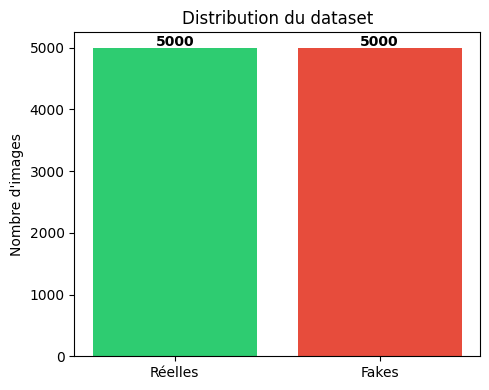

 Dataset détecté correctement.


In [2]:
# Lister les fichiers images
EXTENSIONS = ('.jpg', '.jpeg', '.png')
real_files = [f for f in os.listdir(REAL_DIR) if f.lower().endswith(EXTENSIONS)]
fake_files = [f for f in os.listdir(FAKE_DIR) if f.lower().endswith(EXTENSIONS)]

print(f'Images réelles : {len(real_files)}')
print(f'Images fakes   : {len(fake_files)}')
print(f'Total          : {len(real_files) + len(fake_files)}')

# Sécurité : s'assurer que les dossiers ne sont pas vides
assert len(real_files) > 0, ' Dossier data/real vide !'
assert len(fake_files) > 0, ' Dossier data/fake vide !'

# Visualisation de la distribution
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Réelles', 'Fakes'], [len(real_files), len(fake_files)],
       color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribution du dataset')
ax.set_ylabel('Nombre d\'images')
for i, v in enumerate([len(real_files), len(fake_files)]):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
os.makedirs(r'..\results', exist_ok=True)
plt.savefig(r'..\results\distribution_dataset.png', dpi=150)
plt.show()
print(' Dataset détecté correctement.')

## Example Visualization

We display 5 real and 5 fake images chosen at random to get a visual overview of the dataset.  
The result is also saved in `results/`.


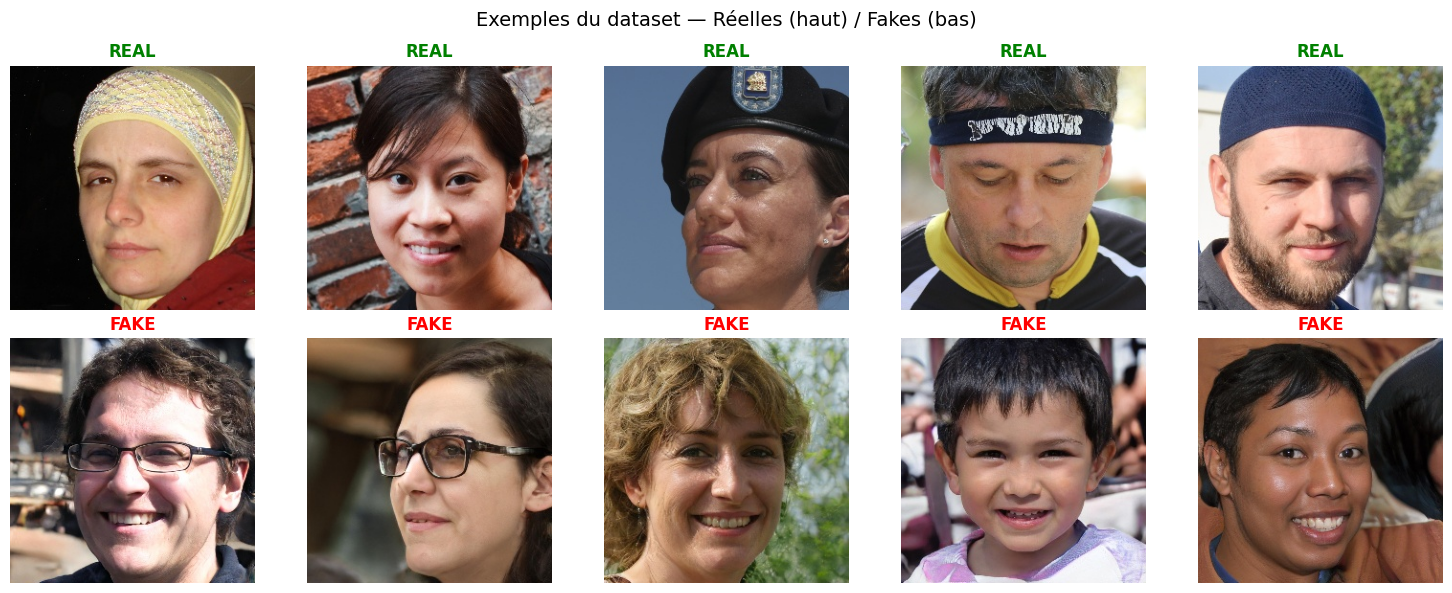

 Visualisation sauvegardée dans results/


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Exemples du dataset — Réelles (haut) / Fakes (bas)', fontsize=14)

for ax in axes[0]:
    img_path = os.path.join(REAL_DIR, random.choice(real_files))
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('REAL', color='green', fontweight='bold')
    ax.axis('off')

for ax in axes[1]:
    img_path = os.path.join(FAKE_DIR, random.choice(fake_files))
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('FAKE', color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(r'..\results\exemples_dataset.png', dpi=150)
plt.show()
print(' Visualisation sauvegardée dans results/')

## Cell 4 — Face Detection with MTCNN

**MTCNN** (Multi-task Cascaded Convolutional Networks) is a highly accurate face detector.  
For each image, we:
1. Detect all faces present
2. Select the one with the highest confidence score
3. Crop and resize to `224×224` px

If no face is detected, the image is skipped (`None`).


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Test MTCNN sur 3 images réelles...
  00000.jpg →  visage trouvé
  00002.jpg →  visage trouvé
  00003.jpg →  visage trouvé


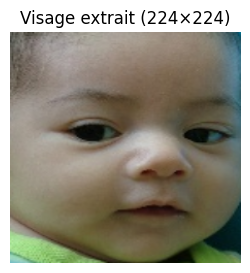

In [4]:
detector = MTCNN()

def extract_face(image_path, img_size=IMG_SIZE):
    """
    Lit une image, détecte le visage avec MTCNN,
    recadre et redimensionne à img_size x img_size.
    Retourne None si aucun visage n'est détecté.
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces   = detector.detect_faces(img_rgb)

        if not faces:
            return None

        # Visage avec la meilleure confiance
        best = max(faces, key=lambda x: x['confidence'])
        x, y, w, h = best['box']
        x, y = max(0, x), max(0, y)   # éviter les coords négatives
        face = img_rgb[y:y+h, x:x+w]
        face = cv2.resize(face, (img_size, img_size))
        return face

    except Exception:
        return None

# ── Test rapide sur 3 images ──
print('Test MTCNN sur 3 images réelles...')
for path in [os.path.join(REAL_DIR, f) for f in real_files[:3]]:
    result = extract_face(path)
    status = ' visage trouvé' if result is not None else '⚠️  pas de visage'
    print(f'  {os.path.basename(path)} → {status}')

# ── Visualiser un visage extrait ──
sample_face = extract_face(os.path.join(REAL_DIR, real_files[0]))
if sample_face is not None:
    plt.figure(figsize=(3, 3))
    plt.imshow(sample_face)
    plt.title('Visage extrait (224×224)')
    plt.axis('off')
    plt.show()

## Complete Face Extraction

This is the longest cell: **10 to 20 minutes** depending on your CPU.  
We iterate through all files in `data/real` and `data/fake`, extract the faces, and build the `X` (images) and `y` (labels: 0=real, 1=fake) arrays.




In [5]:
def load_and_extract(folder, label, max_imgs, img_size=IMG_SIZE):
    """
    Parcourt un dossier, extrait les visages et retourne
    les listes X (images numpy) et y (labels).
    """
    files = [f for f in os.listdir(folder) if f.lower().endswith(EXTENSIONS)]
    random.shuffle(files)
    files = files[:max_imgs]

    X, y, skipped = [], [], 0
    label_name = 'REAL' if label == 0 else 'FAKE'

    for fname in tqdm(files, desc=f'Extraction {label_name}'):
        path = os.path.join(folder, fname)
        face = extract_face(path, img_size)
        if face is not None:
            X.append(face)
            y.append(label)
        else:
            skipped += 1

    print(f'  → Extraites : {len(X)} | Ignorées (pas de visage) : {skipped}')
    return X, y

# ── Lancer l'extraction ──
print(' Extraction REAL (label=0)...')
X_real, y_real = load_and_extract(REAL_DIR, label=0, max_imgs=MAX_IMGS)

print('\n Extraction FAKE (label=1)...')
X_fake, y_fake = load_and_extract(FAKE_DIR, label=1, max_imgs=MAX_IMGS)

# ── Fusionner et mélanger ──
X = np.array(X_real + X_fake, dtype='float32')
y = np.array(y_real + y_fake, dtype='int32')

# Mélanger aléatoirement
indices = np.arange(len(X))
np.random.shuffle(indices)
X, y = X[indices], y[indices]

print(f'\n Dataset final : {X.shape}')
print(f'   Réelles : {sum(y==0)} | Fakes : {sum(y==1)}')

 Extraction REAL (label=0)...


Extraction REAL: 100%|██████████| 2000/2000 [03:32<00:00,  9.42it/s]


  → Extraites : 1997 | Ignorées (pas de visage) : 3

 Extraction FAKE (label=1)...


Extraction FAKE: 100%|██████████| 2000/2000 [03:31<00:00,  9.47it/s]


  → Extraites : 1999 | Ignorées (pas de visage) : 1

 Dataset final : (3996, 224, 224, 3)
   Réelles : 1997 | Fakes : 1999


## Normalization & Train / Val / Test Split

We perform two essential operations:
- **Normalization**: pixel values are scaled from `[0, 255]` → `[0.0, 1.0]` (required by EfficientNet)
- **Stratified split**: we maintain the same real/fake ratio in each subset

| Subset | Proportion | Usage |
|---|---|---|
| Train | 70% | Model training |
| Validation | 15% | Monitoring during training |
| Test | 15% | Final evaluation (unseen data) |


In [6]:
# ── Normalisation ──
X = X / 255.0

# ── Split 70 / 15 / 15 ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print('Tailles des ensembles :')
print(f'  Train      : {X_train.shape[0]} images')
print(f'  Validation : {X_val.shape[0]} images')
print(f'  Test       : {X_test.shape[0]} images')

# ── Vérification de l'équilibre des classes ──
print('\nÉquilibre des classes :')
for name, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    r = 100 * sum(y_s==0) / len(y_s)
    f = 100 * sum(y_s==1) / len(y_s)
    print(f'  {name:5s} → REAL: {r:.1f}%  FAKE: {f:.1f}%')

print('\n Split effectué correctement.')

Tailles des ensembles :
  Train      : 2797 images
  Validation : 599 images
  Test       : 600 images

Équilibre des classes :
  Train → REAL: 50.0%  FAKE: 50.0%
  Val   → REAL: 49.9%  FAKE: 50.1%
  Test  → REAL: 50.0%  FAKE: 50.0%

 Split effectué correctement.


## Visual Verification of the Split

We visualize a few faces extracted from the training set to ensure preprocessing is correct (proper resolution, well-centered faces, successful normalization).


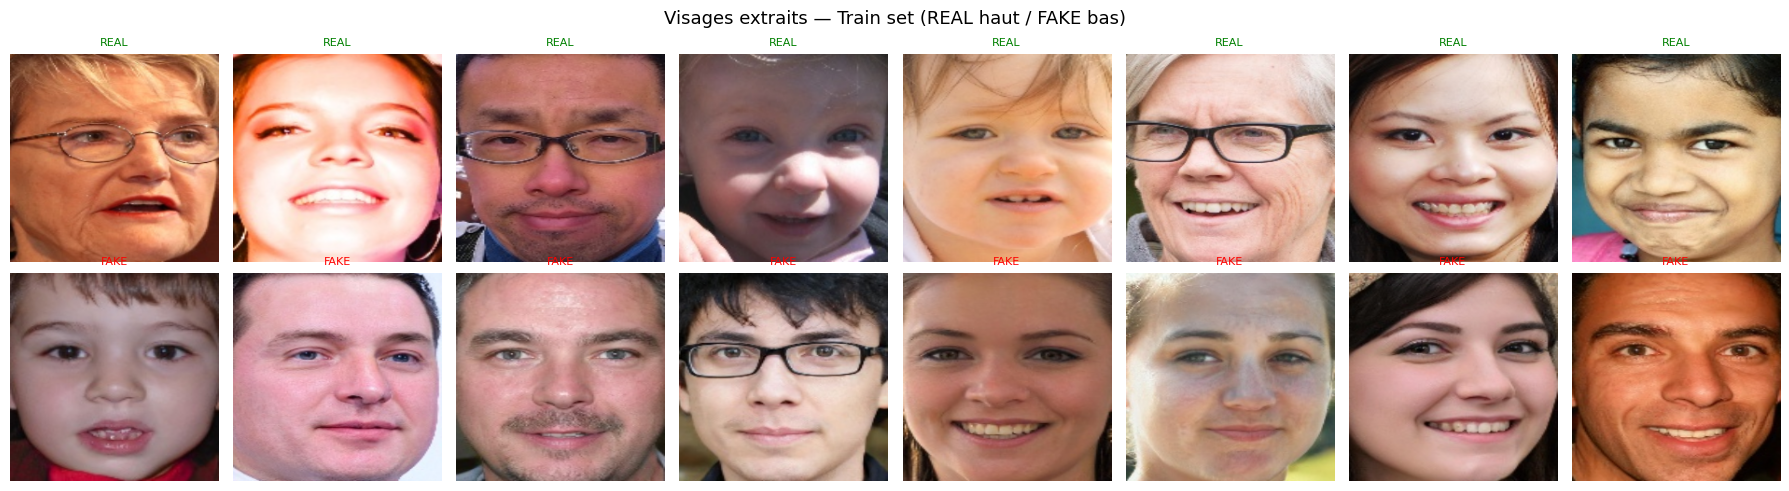

 Aperçu sauvegardé dans results/


In [7]:
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Visages extraits — Train set (REAL haut / FAKE bas)', fontsize=13)

real_idx = np.where(y_train == 0)[0][:8]
fake_idx = np.where(y_train == 1)[0][:8]

for i, idx in enumerate(real_idx):
    axes[0][i].imshow(X_train[idx])
    axes[0][i].set_title('REAL', color='green', fontsize=8)
    axes[0][i].axis('off')

for i, idx in enumerate(fake_idx):
    axes[1][i].imshow(X_train[idx])
    axes[1][i].set_title('FAKE', color='red', fontsize=8)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(r'..\results\visages_extraits_train.png', dpi=150)
plt.show()
print(' Aperçu sauvegardé dans results/')

## Saving Processed Data

We save the 6 NumPy arrays in `data/processed/`.  
These files will be loaded directly in **Notebook 2** for training — no need to repeat the MTCNN extraction.

>  These `.npy` files are several hundred MB each — they are listed in `.gitignore`, so Git will not track them.


In [8]:
PROCESSED_DIR = r'..\data\processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

files_to_save = {
    'X_train.npy': X_train,
    'X_val.npy'  : X_val,
    'X_test.npy' : X_test,
    'y_train.npy': y_train,
    'y_val.npy'  : y_val,
    'y_test.npy' : y_test,
}

for fname, arr in files_to_save.items():
    path = os.path.join(PROCESSED_DIR, fname)
    np.save(path, arr)
    size_mb = os.path.getsize(path) / 1e6
    print(f'   {fname:15s} → {size_mb:.1f} Mo  {arr.shape}')

print('\n- Notebook 1 terminé ! Toutes les données sont prêtes pour l\'entraînement.')
print('   → Prochain fichier : notebooks/02_model_training.ipynb')

   X_train.npy     → 1684.1 Mo  (2797, 224, 224, 3)
   X_val.npy       → 360.7 Mo  (599, 224, 224, 3)
   X_test.npy      → 361.3 Mo  (600, 224, 224, 3)
   y_train.npy     → 0.0 Mo  (2797,)
   y_val.npy       → 0.0 Mo  (599,)
   y_test.npy      → 0.0 Mo  (600,)

- Notebook 1 terminé ! Toutes les données sont prêtes pour l'entraînement.
   → Prochain fichier : notebooks/02_model_training.ipynb


##  Summary — Generated Outputs

| File | Content | Estimated Size |
|---|---|---|
| `data/processed/X_train.npy` | Normalized training images | ~600 MB |
| `data/processed/X_val.npy` | Validation images | ~130 MB |
| `data/processed/X_test.npy` | Test images | ~130 MB |
| `data/processed/y_train.npy` | Training labels | < 1 MB |
| `data/processed/y_val.npy` | Validation labels | < 1 MB |
| `data/processed/y_test.npy` | Test labels | < 1 MB |
| `results/distribution_dataset.png` | Distribution plot | |
| `results/exemples_dataset.png` | Visual examples | |
| `results/visages_extraits_train.png` | Faces after MTCNN | |

**Next notebook:** `02_model_training.ipynb` — EfficientNet-B4 + fine-tuning + callbacks